In [126]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from sklearn.preprocessing import StandardScaler

In [127]:
 file_path = r"C:\Users\Yasindu\Desktop\Stuff\Research\Datasets\Children_ASD.csv"
data = pd.read_csv(file_path)
data.head()

,Unnamed: 0,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10_Autism_Spectrum_Quotient,Age_Years,Sex,Ethnicity,Jaundice,Family_mem_with_ASD,Who_completed_the_test,ASD_traits
0,0,0,0,0,0,0,0,1,1,0,1,2.0,F,Middle Eastern,Yes,No,Family Member,No
1,1,1,1,0,0,0,1,1,0,0,0,3.0,M,White European,Yes,No,Family Member,Yes
2,2,1,0,0,0,0,0,1,1,0,1,3.0,M,Middle Eastern,Yes,No,Family Member,Yes
3,3,1,1,1,1,1,1,1,1,1,1,2.0,M,Hispanic,No,No,Family Member,Yes
4,4,1,1,0,1,1,1,1,1,1,1,1.0,F,White European,No,Yes,Family Member,Yes


In [128]:
# Drop the 'Case_No' column as it's not relevant for modeling
data = data.drop(columns=['Unnamed: 0'])
data = data.drop(columns=['Ethnicity'])

In [129]:
missing_data = data.isnull().sum()
total_missing = missing_data[missing_data > 0].sum()
if total_missing > 0:
    print(f"Total number of missing values in the dataset: {total_missing}")
    print("Missing data by column:")
    print(missing_data[missing_data > 0].to_string())
else:
    print("No missing data in the dataset.")

No missing data in the dataset.


In [130]:
# Drop duplicate rows
data = data.drop_duplicates()

duplicates = data.duplicated().sum()
if duplicates > 0:
    print(f"Total number of duplicate rows in the dataset: {duplicates}")
else:
    print("No duplicate rows in the dataset.")

No duplicate rows in the dataset.


In [131]:
# Check the data types of each column
data_types = data.dtypes
print("Data types of each column:")
print(data_types)

Data types of each column:
A1                                int64
A2                                int64
A3                                int64
A4                                int64
A5                                int64
A6                                int64
A7                                int64
A8                                int64
A9                                int64
A10_Autism_Spectrum_Quotient      int64
Age_Years                       float64
Sex                              object
Jaundice                         object
Family_mem_with_ASD              object
Who_completed_the_test           object
ASD_traits                       object
dtype: object


In [132]:
data = convert_age_to_months(data)

In [133]:
print(data['Age_in_Months'].head())  

0    24
1    36
2    36
3    24
4    12
Name: Age_in_Months, dtype: int64


In [134]:
def convert_age_to_months(data):
    data['Age_in_Months'] = (data['Age_Years'] * 12).astype(int)
    data = data.drop(columns=['Age_Years'])
    return data

In [136]:
# Convert 'Age_Years' to integer (int64)
data['Age_in_Months'] = data['Age_in_Months'].astype('int64')

In [137]:
data_types = data.dtypes
print("Data types of each column:")
print(data_types)

Data types of each column:
A1                               int64
A2                               int64
A3                               int64
A4                               int64
A5                               int64
A6                               int64
A7                               int64
A8                               int64
A9                               int64
A10_Autism_Spectrum_Quotient     int64
Sex                             object
Jaundice                        object
Family_mem_with_ASD             object
Who_completed_the_test          object
ASD_traits                      object
Age_in_Months                    int64
dtype: object


In [138]:
# Ensure data1 is a DataFrame
print(type(data))

<class 'pandas.core.frame.DataFrame'>


In [139]:
# Check basic statistics of numerical columns
numerical_columns = data.select_dtypes(include=['int64', 'float64']).columns

print("Summary statistics of numerical columns:")
print(data[numerical_columns].describe())

Summary statistics of numerical columns:
                A1           A2           A3           A4           A5  \
count  1478.000000  1478.000000  1478.000000  1478.000000  1478.000000   
mean      0.529093     0.414073     0.366035     0.483762     0.491204   
std       0.499322     0.492728     0.481882     0.499905     0.500092   
min       0.000000     0.000000     0.000000     0.000000     0.000000   
25%       0.000000     0.000000     0.000000     0.000000     0.000000   
50%       1.000000     0.000000     0.000000     0.000000     0.000000   
75%       1.000000     1.000000     1.000000     1.000000     1.000000   
max       1.000000     1.000000     1.000000     1.000000     1.000000   

                A6           A7           A8           A9  \
count  1478.000000  1478.000000  1478.000000  1478.000000   
mean      0.537212     0.629229     0.433694     0.449932   
std       0.498782     0.483175     0.495752     0.497655   
min       0.000000     0.000000     0.000000    

In [140]:
age_outliers = data[(data['Age_in_Months'] < (Q1_age - 1.5 * IQR_age)) | (data['Age_in_Months'] > (Q3_age + 1.5 * IQR_age))]

# Display the number of outliers
print(f"Number of outliers in Age_in_Months: {age_outliers.shape[0]}")

Number of outliers in Age_in_Months: 0


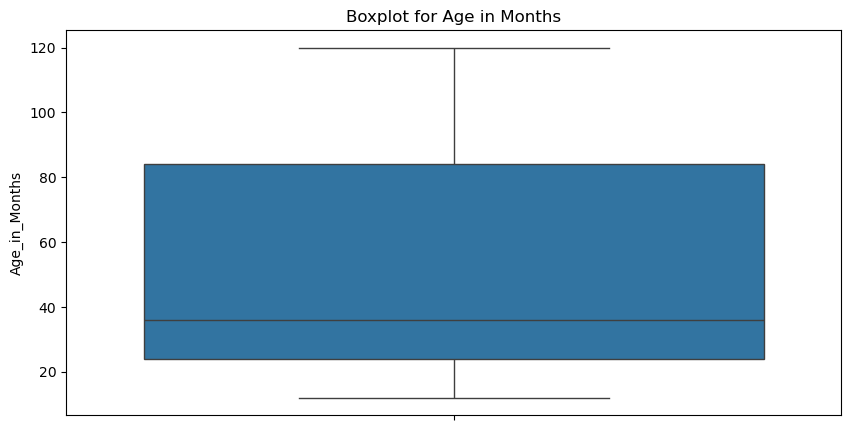

In [141]:
# Boxplot for Age_Mons
plt.figure(figsize=(10, 5))
sns.boxplot(data['Age_in_Months'])
plt.title('Boxplot for Age in Months')
plt.show()

# IQR method for Age_Mons and Qchat-10-Score
Q1_age = data['Age_in_Months'].quantile(0.25)
Q3_age = data['Age_in_Months'].quantile(0.75)
IQR_age = Q3_age - Q1_age


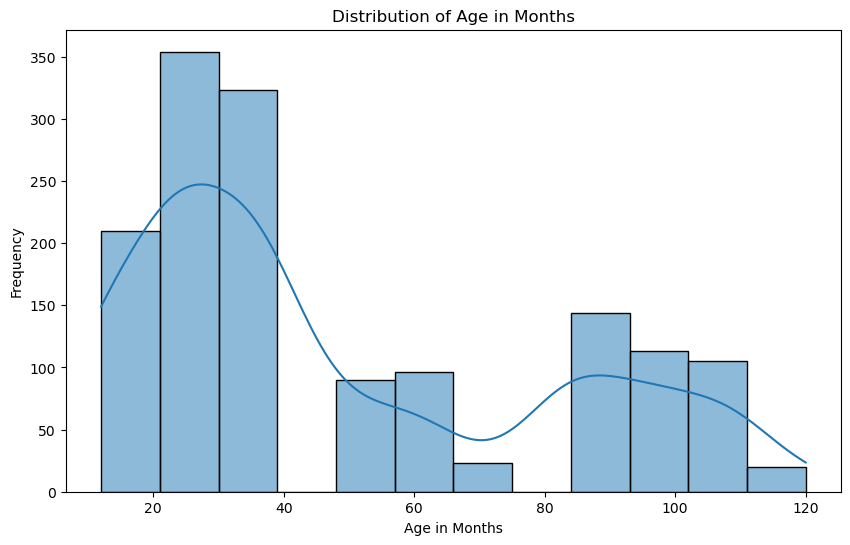

Skewness of Age_in_Months: 0.7322505618706363


In [142]:
# Plot the distribution of 'Age_Mons'
plt.figure(figsize=(10, 6))
sns.histplot(data['Age_in_Months'], kde=True)
plt.title('Distribution of Age in Months')
plt.xlabel('Age in Months')
plt.ylabel('Frequency')
plt.show()

# Check the skewness of the 'Age_Mons' column
age_skewness = skew(data['Age_in_Months'])
print(f"Skewness of Age_in_Months: {age_skewness}")

In [143]:
binary_columns = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10_Autism_Spectrum_Quotient']
for col in binary_columns:
    print(f"Unique values in {col}: {data[col].unique()}")
    print(f"Value counts in {col}: \n{data[col].value_counts()}\n")

Unique values in A1: [0 1]
Value counts in A1: 
A1
1    782
0    696
Name: count, dtype: int64

Unique values in A2: [0 1]
Value counts in A2: 
A2
0    866
1    612
Name: count, dtype: int64

Unique values in A3: [0 1]
Value counts in A3: 
A3
0    937
1    541
Name: count, dtype: int64

Unique values in A4: [0 1]
Value counts in A4: 
A4
0    763
1    715
Name: count, dtype: int64

Unique values in A5: [0 1]
Value counts in A5: 
A5
0    752
1    726
Name: count, dtype: int64

Unique values in A6: [0 1]
Value counts in A6: 
A6
1    794
0    684
Name: count, dtype: int64

Unique values in A7: [1 0]
Value counts in A7: 
A7
1    930
0    548
Name: count, dtype: int64

Unique values in A8: [1 0]
Value counts in A8: 
A8
0    837
1    641
Name: count, dtype: int64

Unique values in A9: [0 1]
Value counts in A9: 
A9
0    813
1    665
Name: count, dtype: int64

Unique values in A10_Autism_Spectrum_Quotient: [1 0]
Value counts in A10_Autism_Spectrum_Quotient: 
A10_Autism_Spectrum_Quotient
1    82

In [144]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Standardize the 'Age_Mons' feature
data['Age_in_Months'] = scaler.fit_transform(data[['Age_in_Months']])

# Show the standardized data
print(data[['Age_in_Months']].head())

   Age_in_Months
0      -0.761438
1      -0.382003
2      -0.382003
3      -0.761438
4      -1.140874


In [145]:
# Identify categorical columns
categorical_columns = data.select_dtypes(include=['object']).columns
print("\nCategorical columns identified:")
print(categorical_columns)


Categorical columns identified:
Index(['Sex', 'Jaundice', 'Family_mem_with_ASD', 'Who_completed_the_test',
       'ASD_traits'],
      dtype='object')


In [146]:
# Inspect unique values in each categorical column
for col in categorical_columns:
    print(f"Unique values in {col}:")
    print(data[col].unique())
    print("\n")

Unique values in Sex:
['F' 'M']


Unique values in Jaundice:
['Yes' 'No']


Unique values in Family_mem_with_ASD:
['No' 'Yes']


Unique values in Who_completed_the_test:
['Family Member' 'Health Care Professional' 'Self' 'Others'
 'School and NGO']


Unique values in ASD_traits:
['No' 'Yes']




In [147]:
# Replace 'Self' with 'Others' in the same column
data['Who_completed_the_test'] = data['Who_completed_the_test'].replace({'Self': 'Others'})

# Verify the replacement
print(data['Who_completed_the_test'].unique())


['Family Member' 'Health Care Professional' 'Others' 'School and NGO']


In [148]:
# Identify categorical columns
categorical_columns = data.select_dtypes(include=['object']).columns
print("\nCategorical columns identified:")
print(categorical_columns)


Categorical columns identified:
Index(['Sex', 'Jaundice', 'Family_mem_with_ASD', 'Who_completed_the_test',
       'ASD_traits'],
      dtype='object')


In [149]:
# One-hot encode categorical columns
data_encoded = pd.get_dummies(data, columns=categorical_columns, drop_first=True)

# Identify the new one-hot encoded columns
encoded_categorical_columns = [col for col in data_encoded.columns if col not in data.columns]

# Show the first few rows of the newly encoded categorical columns
encoded_categorical_data = data_encoded[encoded_categorical_columns]
# print(encoded_categorical_data.head())

In [150]:
# Check the data types of each column
data_types =data_encoded.dtypes
print("Data types of each column:")
print(data_types)

Data types of each column:
A1                                                   int64
A2                                                   int64
A3                                                   int64
A4                                                   int64
A5                                                   int64
A6                                                   int64
A7                                                   int64
A8                                                   int64
A9                                                   int64
A10_Autism_Spectrum_Quotient                         int64
Age_in_Months                                      float64
Sex_M                                                 bool
Jaundice_Yes                                          bool
Family_mem_with_ASD_Yes                               bool
Who_completed_the_test_Health Care Professional       bool
Who_completed_the_test_Others                         bool
Who_completed_the_test_School

In [151]:
data_types =data_encoded.dtypes
print("Data types of each column:")
print(data_types)

Data types of each column:
A1                                                   int64
A2                                                   int64
A3                                                   int64
A4                                                   int64
A5                                                   int64
A6                                                   int64
A7                                                   int64
A8                                                   int64
A9                                                   int64
A10_Autism_Spectrum_Quotient                         int64
Age_in_Months                                      float64
Sex_M                                                 bool
Jaundice_Yes                                          bool
Family_mem_with_ASD_Yes                               bool
Who_completed_the_test_Health Care Professional       bool
Who_completed_the_test_Others                         bool
Who_completed_the_test_School

In [152]:
print(data_encoded['Age_in_Months'].unique()) 

[-0.76143832 -0.38200277 -1.14087387 -0.00256722  0.37686833  1.89461053
  0.75630388  1.51517498  1.13573943  2.27404608]


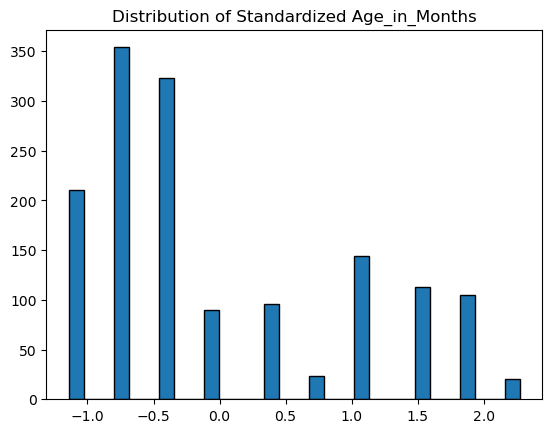

In [153]:
# Plot the distribution of the standardized 'Age_Years'
plt.hist(data_encoded['Age_in_Months'], bins=30, edgecolor='black')
plt.title('Distribution of Standardized Age_in_Months')
plt.show()

In [156]:
data['Age_in_Months'] = data['Age_in_Months'].astype(int)

In [158]:
print(data_types)


A1                                                   int64
A2                                                   int64
A3                                                   int64
A4                                                   int64
A5                                                   int64
A6                                                   int64
A7                                                   int64
A8                                                   int64
A9                                                   int64
A10_Autism_Spectrum_Quotient                         int64
Age_in_Months                                      float64
Sex_M                                                 bool
Jaundice_Yes                                          bool
Family_mem_with_ASD_Yes                               bool
Who_completed_the_test_Health Care Professional       bool
Who_completed_the_test_Others                         bool
Who_completed_the_test_School and NGO                 bo

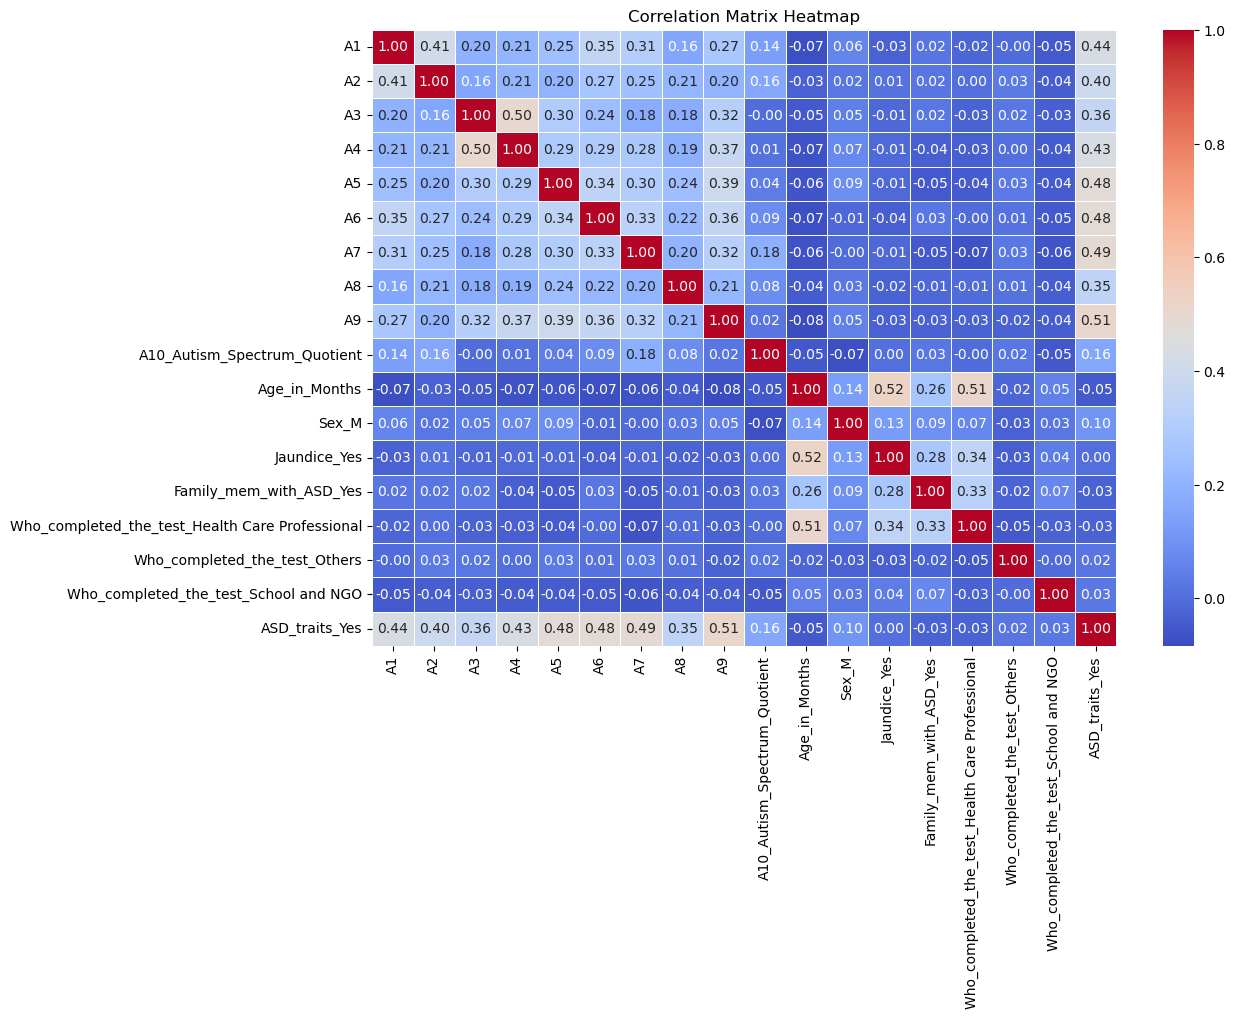

In [161]:
# Compute the correlation matrix
correlation_matrix = data_encoded.corr()
# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

In [164]:
# Save the pre-processed data to a CSV file
output_file_path = r"C:\Users\Yasindu\Desktop\Stuff\Research\Datasets\PrePROCESSED DATA\pre_processed_data2.csv"
data_encoded.to_csv(output_file_path, index=False)